In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import datetime as dt
import numpy as np
import xarray as xr
import pftnames
import utils
import grainc_global
#from scipy import stats, signal
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask
import glob
import os
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.metrics import r2_score, mean_squared_error

79


### 1. load and reformat datasets

In [2]:
YR1, YR2          = 1985,2014
root              = f''
dir_DER           = f'{root}/apps/CTSM_dev/DERECHO_OUT/'
active_crops      = ['wheat', 'corn', 'rice', 'soybean', 'cotton', 'sugarcane']
crop_dict_clm_fao = { "wheat": "wheat", "corn": "maize", "rice": "rice", 
                     "soybean": "soybean", "cotton": "cotton", "sugarcane": "sugarcane"}
exps              = 'harmonized_exps_lai_rep'

#minimum number of heatwave days
HW_ndays          = 8

#parameters of for locations with overlappig grainfill stages in calendar years:
nyears_overlap   = 5
R_improvement    = 0.3

#### a. --------------- landuse map for area data

In [17]:
luds_name = f'{root}/data/processed/clm_2deg/area/'\
            f'landuse.timeseries_1.9x2.5_SSP2-4.5_1850-2100_78pfts_c240216.nc'

#load in dummy ds_clm 
clm_ds = xr.open_dataset(f'{dir_DER}ihist.e52.IHistClm50BgcCrop.f19_g17.nostress_1980/ihist.e52.IHistClm50BgcCrop.f19_g17.nostress_1980.clm2.h4.1980-01-01-00000.nc')

grid_luds = grainc_global.open_lu_ds(luds_name, YR1, YR2, clm_ds, ungrid=False)

#land use data processing (add Area)
grid_luds['AREA_CFT']       = grid_luds.AREA*1e6 * grid_luds['LANDFRAC'] * (grid_luds.PCT_CROP/100) * (grid_luds.PCT_CFT/100)
grid_luds['AREA_CFT'].attrs = {'units': 'm2'}

#correct land use dataset
grid_luds['cft']                   = pftnames.pftname[15:]


clm_ds.close()

#### b. --------------- load in yield data CLM experiments

In [4]:
file_pattern = os.path.join(dir_DER, f'{exps}/*/ihist.*.*.clm2.h4.*-01-01-00000.nc')
files        = sorted(glob.glob(file_pattern))

datasets_dict ={}
for f in files[:]:
    #exp name
    exp_key = f"ds{f.split('HSF')[-1].split('.')[0]}"
    if exp_key == 'ds_TVpeak_REP_allvars_3':
        exp_key = 'ds_TVpeak_REP_3'
    print(exp_key)

    #open ds
    clm_ds = xr.open_dataset(f)
    
    # --------- annual output is output last day of previous year (e.g. 1980.01.01 == 1979.12.31)
    clm_ds['time']  = clm_ds['time'] - dt.timedelta(days=1)
    clm_ds['time']= clm_ds.time.dt.year
    
    # --------- go from reproductive C to yield carbon (using Sam Rabin's code pieces):
    clm_ds['pft1d_itype_veg_str'] = np.array(pftnames.pftname)[clm_ds['pfts1d_itype_veg'].values.astype(int)]
    clm_ds['grain_harvest']       = grainc_global.adjust_grainC(clm_ds['GRAINC_TO_FOOD_ANN'],
                                                                clm_ds['pft1d_itype_veg_str'])
    
    # --------- pft to grid
    grain_grid                    = grainc_global.reshape_1D_to_2Dgrid('grain_harvest', 
                                                                       clm_ds, mask =None)
    grain_grid                    = grain_grid.rename({'pft':'cft'})

    # grain harvest to yield
    clm_yield = grainc_global.global_production_yield(grid_luds['AREA_CFT'], 
                                                     grain_grid, YR1, YR2, active_crops)

    # change lon axis to -180,180
    clm_yield = utils.lon_pm2idl(clm_yield)
    
    clm_yield = clm_yield.rename({'cfts_grouped': 'crop'})
    clm_yield= clm_yield.transpose('time', 'crop', 'lat', 'lon')

    # --------- append to dictionary
    datasets_dict[exp_key] = clm_yield

ds_nostress
ds_TVpeak_LAI_1
ds_TVpeak_LAI_2
ds_TVpeak_LAI_3
ds_TVpeak_LAI_4
ds_TVpeak_LAI_5
ds_TVpeak_LAI_6
ds_TVpeak_REP_1
ds_TVpeak_REP_2
ds_TVpeak_REP_3
ds_TVpeak_REP_4
ds_TVpeak_REP_5
ds_TVpeak_REP_6


#### c. --------------- load in yield data reference ESFAO dataset

In [5]:
# -- EARTHSTAT FAO YIELD
path_fao       = f'/dodrio/scratch/users/vsc10951/sderoos/data/external/yield_ncarunfaoearthstat/'
ds_fao         = xr.open_dataset(f'{path_fao}ESFAODeg2.nc')
ds_fao         = ds_fao.assign_coords({"lat": grain_grid['lat'].values,
                                       "lon": grain_grid['lon'].values, 
                                       "crop":utils.ESFAO_croplist()})
ds_fao         = ds_fao.assign_coords(time=xr.DataArray([t.year for t in ds_fao.time.values],
                                                        dims="time"))
ds_fao         = ds_fao.sel(time=slice(YR1, YR2))

if ds_fao.lon.values.max() > 300:
    ds_fao = utils.lon_pm2idl(ds_fao)

#select crops from croplist:
ds_fao = ds_fao.sel(crop=list(crop_dict_clm_fao.values()))
inv_map = {v: k for k, v in crop_dict_clm_fao.items()}
ds_fao = ds_fao.assign_coords(
    crop=[inv_map[c] for c in ds_fao['crop'].values]
)

#### d. --------------- load in GSWP Temperature anomaly mask to get the locations for crops with overlapping calendar year growing seasons.

In [6]:
txmask  = xr.open_dataset(f'{root}/paper1/TX_95p_GF3_mask_1985_2014.nc')
txmask  = grainc_global.cft_to_crops(txmask)
txmask  = txmask.rename({'year': 'time'})

### 2. functions

#### a. --------------- detrend yield functions

In [7]:
def detrend_yield(ds_yield_years, T_dim='year', fit_degree =1):
    ''' 
    detrend yield based on linear or quadratic trend

    Parameters:
    - ds_yield_years: xarray DataArray of yield with time dimension T_dim
    - T_dim: str, name of the time dimension (default 'year')
    - fit_degree: 1 = linear 2 = quadratic
    
    Returns:
    - xarray DataArray of standardized yield anomalies
    '''
    # Fit a linear trend (degree=1)
    poly_coeffs = ds_yield_years.polyfit(dim=T_dim, deg=fit_degree)

    # Compute the trend line
    valid_mask = ds_yield_years.notnull()
    trend = xr.polyval(ds_yield_years[T_dim], poly_coeffs.polyfit_coefficients).where(valid_mask)
    
    # Detrend by subtracting the trend
    residuals = ds_yield_years - trend
    return residuals, trend

In [8]:
def standardized_yield_anomalies(residuals, T_dim='year'):
    '''
    Compute standardized yield anomalies, i.e. the zscore.
    
    Parameters:
    - ds_yield_years: xarray DataArray of yield with time dimension T_dim
    - T_dim: str, name of the time dimension (default 'year')
    
    Returns:
    - xarray DataArray of standardized yield anomalies
    '''


    # Step 2: Compute mean and std along time
    # use mean over time (which should be zero, to be consistent with the formal z-score definition)
    residuals_mean = residuals.mean(dim=T_dim)
    residuals_std = residuals.std(dim=T_dim, ddof=1)

    # Step 3: Standardize
    standardized_anom = (residuals - residuals_mean) / residuals_std

    return standardized_anom

In [9]:
def yield_detrend_ds(clm_yield, fao_yield):
    ''' Detrend both CLM and ESFAO (reference) dataset, while harmonize both datasets'''
    
    #check that dimensions order and length is the same
    if len(fao_yield.crop.values) == len(clm_yield.crop.values) and fao_yield.crop[0].values==clm_yield.crop[0].values:
        
        def clean_mask(arr):
            arr = arr.where(arr >= 0.001)
            return arr.where(arr.count(dim='time') >= 10)
        
        fao_clean = clean_mask(fao_yield)
        clm_clean = clean_mask(clm_yield)
        
        joint = fao_clean.notnull() & clm_clean.notnull()
        
        fao_masked = fao_clean.where(joint)
        clm_masked = clm_clean.where(joint)
        
        fao_res, fao_trend = detrend_yield(fao_masked, T_dim='time', fit_degree =2)
        clm_res, clm_trend = detrend_yield(clm_masked, T_dim='time', fit_degree =2)
        
        fao_sd  = standardized_yield_anomalies(fao_res, T_dim='time')
        clm_sd  = standardized_yield_anomalies(clm_res, T_dim='time')
        
            # build final dataset
        dataset_detrended = xr.Dataset(
            {
                "clm_yield_abs": clm_masked,
                "fao_yield_abs": fao_masked,
                "clm_yield_detrend": clm_res,
                "fao_yield_detrend": fao_res,
                "clm_yield_trend": clm_trend,
                "fao_yield_trend": fao_trend,
                "clm_yield_SYA": clm_sd,
                "fao_yield_SYA": fao_sd,
            }
        )

    else:
        print('datasets do not match, check crops!')
    return dataset_detrended

#### b. --------------- metric calculation functions

In [10]:
def calc_rmse(ds, ds_fao):
    rmse = np.sqrt(((ds - ds_fao) ** 2).mean(dim='time', skipna=True))
    return rmse

#### b. --------------- Crop-specific area masks (for dotplots)

In [11]:
crop_dict = {
    'wheat': ['spring_wheat', 'irrigated_spring_wheat',
          'winter_wheat', 'irrigated_winter_wheat'],

    'corn': ['temperate_corn', 'irrigated_temperate_corn',
           'tropical_corn', 'irrigated_tropical_corn'],

    'rice': ['rice', 'irrigated_rice'],

    'soybean': ['soybean', 'irrigated_soybean',
           'tropical_soybean', 'irrigated_tropical_soybean']
}

croparea = {}

for crop_name, cft_list in crop_dict.items():

    crop_ts = (
        grid_luds['AREA_CFT']
        .sel(cft=cft_list)
        .sum(dim='cft')
    )

    # Number of years with crop area > 0
    n_years_present = (crop_ts > 0).sum(dim='time')

    # Require at least 20 occurrences
    persistence_mask = n_years_present >= 20

    # Mean area through time
    ds_crop = crop_ts.mean(dim='time')

    # Apply persistence criterion
    ds_crop = ds_crop.where(persistence_mask)

    croparea[crop_name] = utils.lon_pm2idl(ds_crop)

### 3. Analyses

In [12]:
ds_detrends_dict ={}
for exp_clm in datasets_dict:
    detrend_ds = yield_detrend_ds(datasets_dict[exp_clm]['yield_crop'], ds_fao['Yield'])
    name       = exp_clm 
    ds_detrends_dict[name] = detrend_ds

#### a. --------------- yield maps

##### YIELD IMPACT: FAO yield filtered on GWSP air temperature during CPHASE3

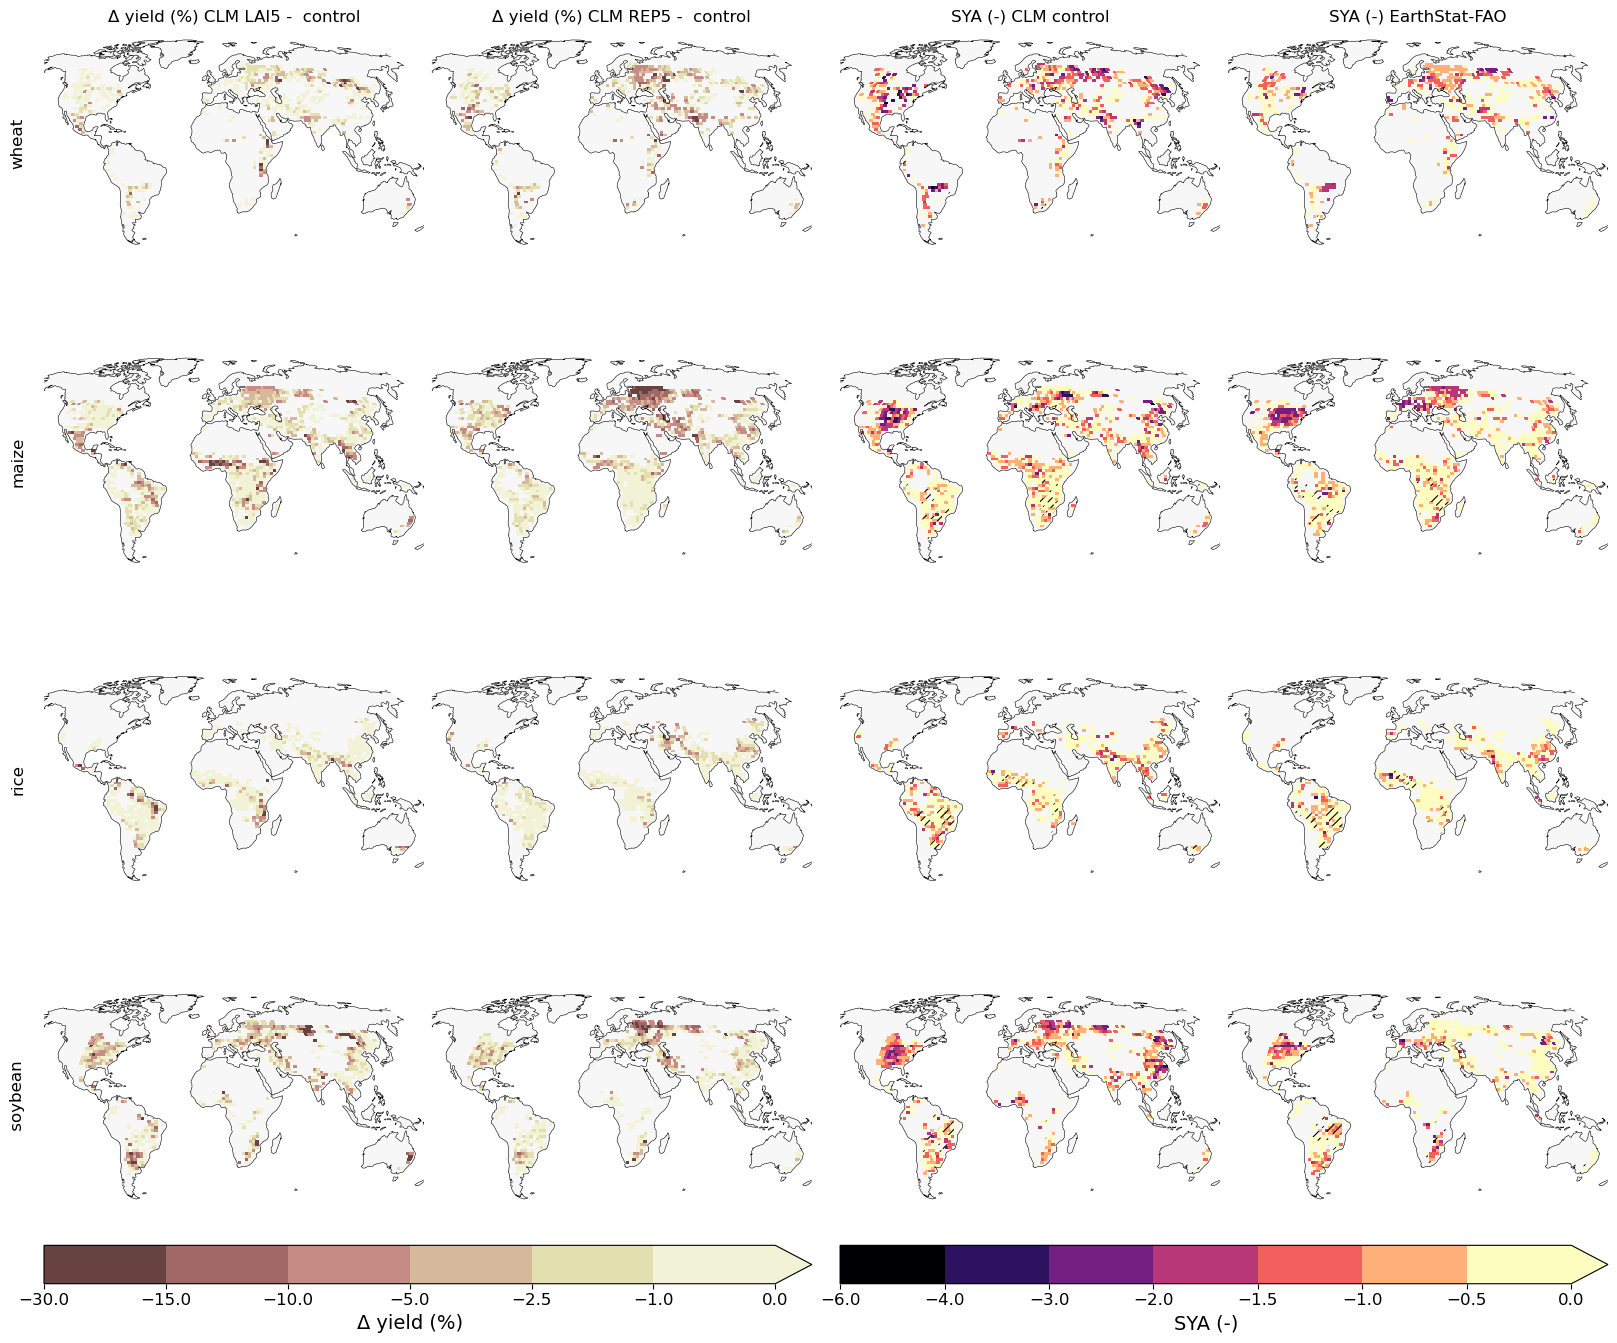

In [13]:
exp = '5'
explai = 'ds_TVpeak_LAI_'+ exp
exprep = 'ds_TVpeak_REP_'+ exp
exp0 ='ds_nostress'


# Colormaps ----------------------------------------

# Difference maps (LAI and REP)
diff_bounds = [-30, -15, -10,-5,-2.5,-1,0] #[-2, -1, -0.5, -0.3,-0.2,-0.1,-0.05,-0.01,0]
adj_cbar = plt.cm.pink(np.linspace(0.1, 0.85, len(diff_bounds)-1))
diff_cmap = mcolors.ListedColormap(adj_cbar)
diff_norm = mcolors.BoundaryNorm(diff_bounds, diff_cmap.N)

# Absolute yields (Control and FAO)
yield_bounds = [-6, -4, -3,-2,-1.5,-1,-0.5,0]
#yield_bounds = [-40,-30,-20,-15,-10,-5,0]
yield_cmap = plt.get_cmap("magma", len(yield_bounds)-1)
yield_norm = mcolors.BoundaryNorm(yield_bounds, yield_cmap.N)


# Figure ----------------------------------------

fig, axes = plt.subplots(
    4,
    4,
    figsize=(16,14),
    subplot_kw=dict(projection=ccrs.Robinson()),
    constrained_layout=True
)
fig.set_constrained_layout_pads(
    hspace=0.005,  # default ~0.02
    wspace=0.02,
    h_pad=0.01,
    w_pad=0.01
)

crop_names = ['wheat', 'maize', 'rice', ' soybean']

              
for cropi in range(4):

    # --- CLM data ---
    ds_SYA = ds_detrends_dict[exp0]['clm_yield_SYA'][:,cropi,:,:]
    ds_abs = ds_detrends_dict[exp0]['clm_yield_abs'][:,cropi,:,:]
    fao_detrend = ds_detrends_dict[exp0]['fao_yield_detrend'][:,cropi,:,:]
    fao_trend = ds_detrends_dict[exp0]['fao_yield_trend'][:,cropi,:,:]
    ds_detrend = ds_detrends_dict[exp0]['clm_yield_detrend'][:,cropi,:,:]
    ds_trend = ds_detrends_dict[exp0]['clm_yield_trend'][:,cropi,:,:]
    ds_LAI_SYA = ds_detrends_dict[explai]['clm_yield_SYA'][:,cropi,:,:]
    ds_REP_SYA = ds_detrends_dict[exprep]['clm_yield_SYA'][:,cropi,:,:]
    ds_LAI_abs = ds_detrends_dict[explai]['clm_yield_abs'][:,cropi,:,:]
    ds_REP_abs = ds_detrends_dict[exprep]['clm_yield_abs'][:,cropi,:,:]


    #FAO reference data
    fao_SYA = ds_detrends_dict[exp0]['fao_yield_SYA'][:,cropi,:,:]

    # ------ if CPHASE 2 or 3 is simulated end of year --> check for better fit with previous reference year
    # minimum x years with a growing season overlapping the new calendar year
    GS_risk = txmask['Tanom_transition'][cropi,:,:,:]
    GS_risk_mask = GS_risk.notnull().sum(dim='time') >= nyears_overlap 
    
    # Correlations used to diagnose timing mismatch
    corr0 = xr.corr(fao_SYA, ds_SYA, dim='time')
    corr1 = xr.corr(fao_SYA.shift(time=1), ds_SYA, dim='time')
    
    # Shift only where improvement is meaningful
    shift_mask = (
        GS_risk_mask &
        ((corr1 - corr0) > R_improvement)
    )
    
    # Apply shift to SYA
    shift_mask_3d = shift_mask.broadcast_like(fao_SYA)
    
    fao_SYA_corrected = xr.where(
        shift_mask_3d,
        fao_SYA.shift(time=1),
        fao_SYA)
    # -------------------------------

    # temperature anomalies
    Tanom_years = txmask['Tanom_phase3'][cropi,:,:,:] >= HW_ndays
    
    # filter reference data on 'extreme years during CPHASE3 and negative yields
    fao_SYA_maskT = fao_SYA_corrected.where(Tanom_years)
    valid_mask = fao_SYA_maskT.notnull()
    #filter other data on the same mask
    ds_SYA_maskT = ds_SYA.where(valid_mask)
    ds_LAI_SYA_maskT = (((ds_LAI_abs - ds_abs)/ds_abs)*100).where(valid_mask)
    ds_REP_SYA_maskT = (((ds_REP_abs - ds_abs)/ds_abs)*100).where(valid_mask)


    # plot mean:
    clm_expLAI  = ds_LAI_SYA_maskT.mean(dim='time')     # method 1: LAI
    clm_expREP  = ds_REP_SYA_maskT.mean(dim='time')     # method 2: REP     
    clm_control = ds_SYA_maskT.mean(dim='time')         # CLM control
    fao         = fao_SYA_maskT.mean(dim='time')        # Earthstat-FAO

    
    
    #inserted
    maps = [
        clm_expLAI,
        clm_expREP,
        clm_control,
        fao
    ]

    for coli, da in enumerate(maps):

        ax = axes[cropi, coli]

        # choose colormap
        if coli < 2:
            cmap = diff_cmap
            norm = diff_norm
        else:
            cmap = yield_cmap
            norm = yield_norm

        im = ax.pcolormesh(
            da.lon,
            da.lat,
            da,
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            norm=norm,
            rasterized=True
        )

        # Robinson zoom
        ax.set_extent(
            [-125,155,-60,90],
            crs=ccrs.PlateCarree()
        )
        ax.add_feature(
        cfeature.LAND,
        facecolor='0.97')

        ax.coastlines(
            linewidth=0.4,
            color='black'
        )

        # remove globe outline
        if hasattr(ax, "spines"):
            ax.spines["geo"].set_visible(False)

        # crop labels
        if coli == 0:
            ax.set_title("")
            ax.text(
                -0.05,
                0.5,
                crop_names[cropi],
                rotation=90,
                va='center',
                ha='right',
                transform=ax.transAxes,
                fontsize=12
            )

        # column titles
        if cropi == 0:

            titles = [
                "Δ yield (%) CLM LAI5 -  control",
                "Δ yield (%) CLM REP5 -  control",
                "SYA (-) CLM control",
                "SYA (-) EarthStat-FAO"
            ]

            ax.set_title(
                titles[coli],
                fontsize=12,
                pad=10
            )

        if coli == 2 or coli == 3:
            plt.rcParams['hatch.color'] = 'k'
            plt.rcParams['hatch.linewidth'] = 0.8

            
            ax.contourf(
                shift_mask.lon,
                shift_mask.lat,
                shift_mask.astype(int),
                levels=[0.5,1.5],
                hatches=['////'],
                colors='none',
                transform=ccrs.PlateCarree()
            )

# ----------------------------------------
# Shared colorbars
# ----------------------------------------

cbar1 = fig.colorbar(
    plt.cm.ScalarMappable(
        norm=diff_norm,
        cmap=diff_cmap
    ),
    ax=axes[:,0:2],
    orientation='horizontal',
    fraction=0.04,
    pad=0.03,
    location='bottom',
    extend='max'
)

cbar1.ax.tick_params(labelsize=12)
cbar1.set_label(
    'Δ yield (%)',fontsize=14
)


cbar2 = fig.colorbar(
    plt.cm.ScalarMappable(
        norm=yield_norm,
        cmap=yield_cmap
    ),
    ax=axes[:,2:4],
    orientation='horizontal',
    fraction=0.04,
    pad=0.03,
    location='bottom',
    extend='max'
)

cbar2.ax.tick_params(labelsize=12)
cbar2.set_label(
    "SYA (-)",fontsize=14
)


#plt.savefig(f'{root}/paper1/figs/yield_impactfreq_quadr_{exp}_anomT.jpeg',dpi=400)

plt.show()

##### year-specific events

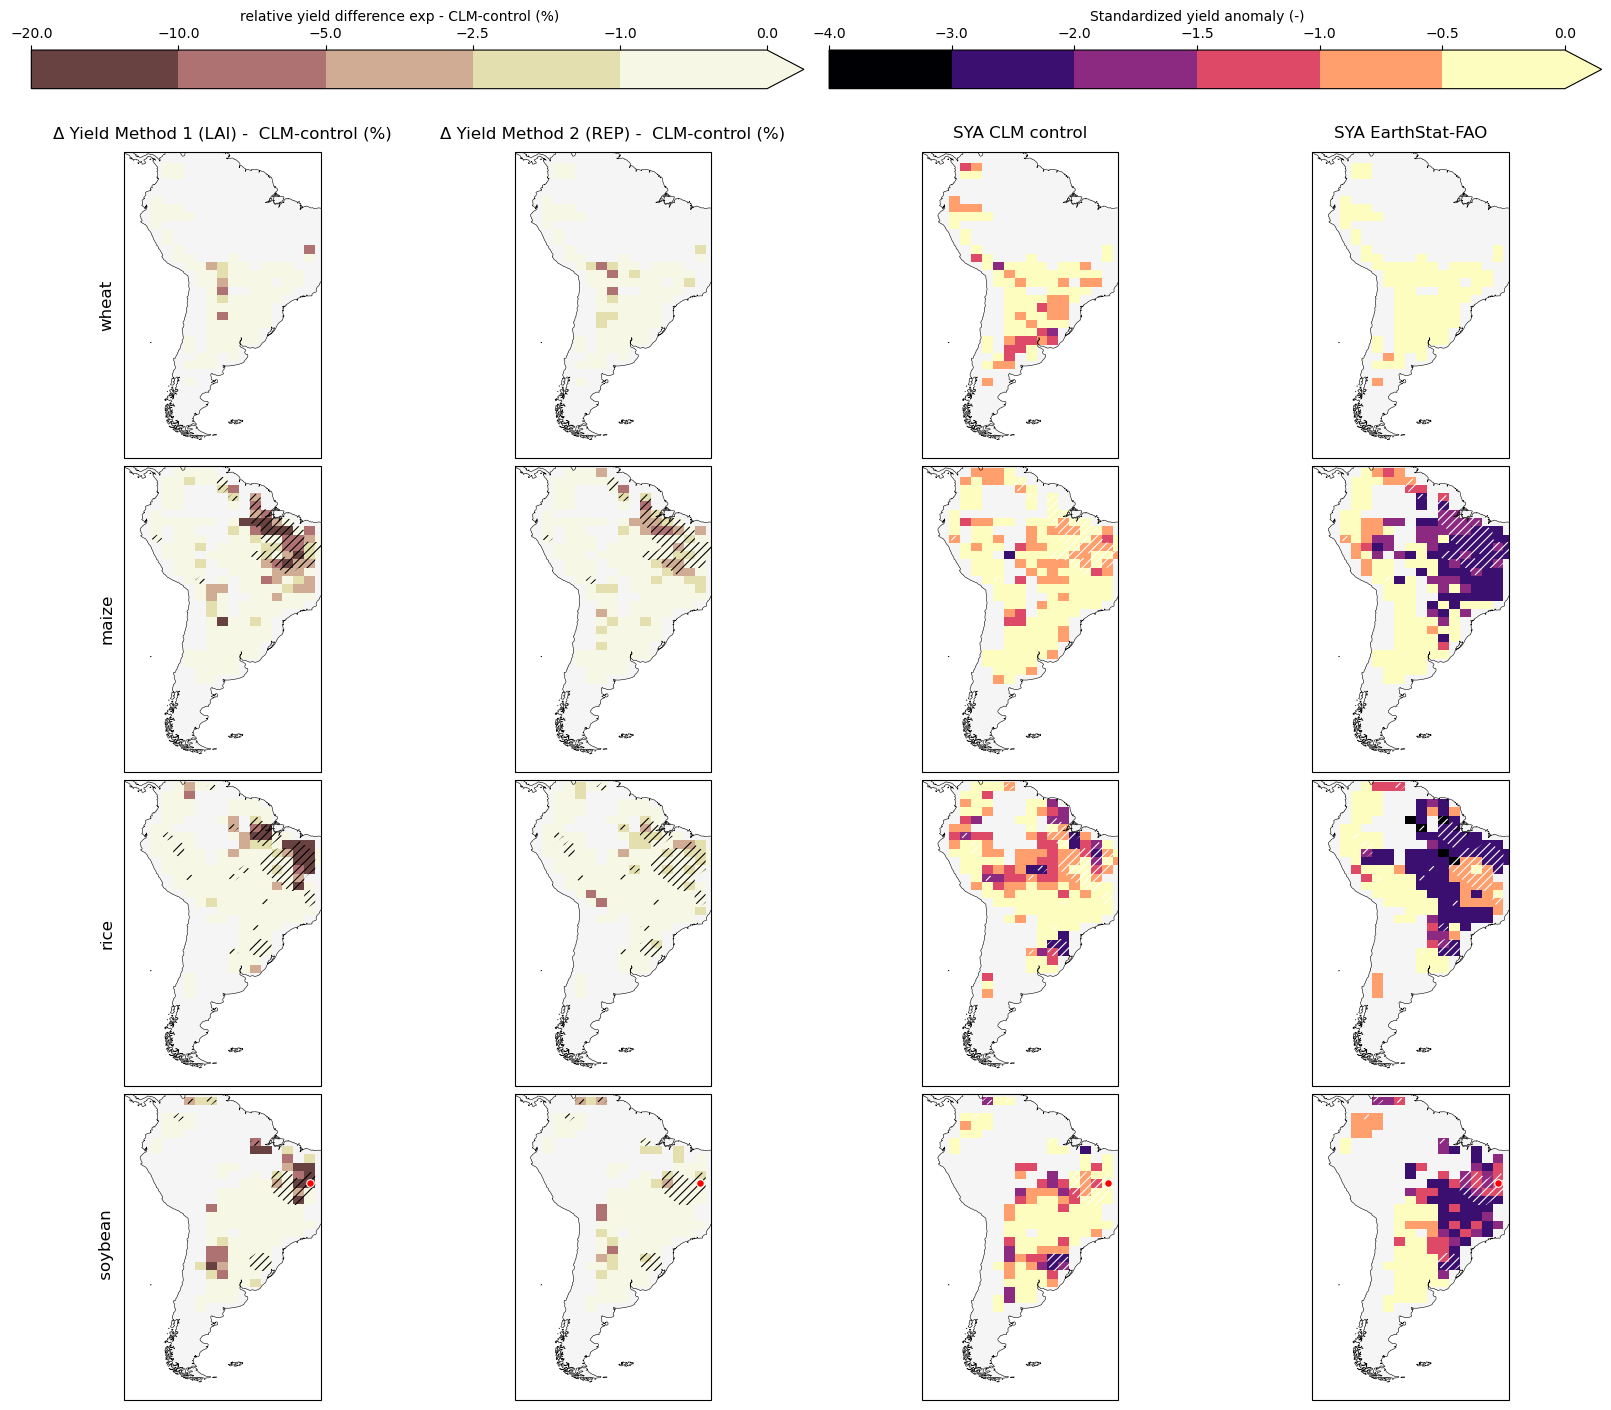

In [15]:
year = 2005
exp = '5'
explai = 'ds_TVpeak_LAI_'+ exp
exprep = 'ds_TVpeak_REP_'+ exp
exp0 ='ds_nostress'
diff_SYA = 0  # we want to look at areas of negative yield anomalies


#zoom in:
lats_zoom = {'LA':(-85, -40),'RU':(20, 80), 'EU':(-15, 40),'US':(-120),'WS':(-20,30)}
lon_min, lon_max = -85, -40 #EURAS:20, 80 #LA:(-90, -20) #EU:-15, 40 
lat_min, lat_max = -60, 10  #EURAS:40, 70 #LA: -60, 10  70 #EU:30, 70 
region = 'LA'#'EURAS'

# location to highlight
crop_ts = 3
pt_lat = -10.4 #50.2 #57.8 #-10.4 #50
pt_lon = -42.5#-45 #7.5 #47.5 #-42.5 #59.7




# ----------------------------------------
# Colormaps
# ----------------------------------------

# Difference maps (LAI and REP)
diff_bounds = [-20,-10,-5,-2.5,-1,0] 
adj_cbar    = plt.cm.pink(np.linspace(0.1, 0.90, len(diff_bounds)-1))
diff_cmap   =  mcolors.ListedColormap(adj_cbar)
diff_norm   = mcolors.BoundaryNorm(diff_bounds, diff_cmap.N)

# Absolute yields (Control and FAO)
yield_bounds =  [-4, -3,-2,-1.5,-1,-0.5,0]
yield_cmap = plt.get_cmap("magma", len(yield_bounds)-1)
yield_norm = mcolors.BoundaryNorm(yield_bounds, yield_cmap.N)

# ----------------------------------------
# Figure
# ----------------------------------------

fig, axes = plt.subplots(
    4,
    4,
    figsize=(16,14),
    subplot_kw=dict(projection=ccrs.PlateCarree()),
    constrained_layout=True
)

crop_names = ['wheat', 'maize', 'rice', ' soybean']

for cropi in range(4):
    yr_idx = np.where(ds_detrends_dict[exp0]['time']==year)[0]
    
    # --- CLM data  ---
    ds_SYA = ds_detrends_dict[exp0]['clm_yield_SYA'][yr_idx,cropi,:,:].squeeze()
    ds_abs = ds_detrends_dict[exp0]['clm_yield_abs'][yr_idx,cropi,:,:].squeeze()
    ds_LAI_SYA = ds_detrends_dict[explai]['clm_yield_SYA'][yr_idx,cropi,:,:].squeeze()
    ds_REP_SYA = ds_detrends_dict[exprep]['clm_yield_SYA'][yr_idx,cropi,:,:].squeeze()
    ds_LAI_abs = ds_detrends_dict[explai]['clm_yield_abs'][yr_idx,cropi,:,:].squeeze()
    ds_REP_abs = ds_detrends_dict[exprep]['clm_yield_abs'][yr_idx,cropi,:,:].squeeze()

    #FAO reference data
    fao_all = ds_detrends_dict[exp0]['fao_yield_SYA'][:, cropi, :, :]
    clm_all = ds_detrends_dict[exp0]['clm_yield_SYA'][:, cropi, :, :]

    # ------ If CPHASE 2 or 3 is simulated end of year --> check for better fit with previous reference year
    #minimum x years with a growing season overlapping the new calendar year
    GS_risk = txmask['Tanom_transition'][cropi,:,:,:]
    GS_risk_mask = GS_risk.notnull().sum(dim='time') >= nyears_overlap 
    
    # Correlations used to diagnose timing mismatch
    corr0 = xr.corr(fao_all,clm_all, dim='time')
    corr1 = xr.corr(fao_all.shift(time=1), clm_all, dim='time')
    
    # Shift only where improvement is meaningful
    shift_mask = (
        GS_risk_mask &
        ((corr1 - corr0) > R_improvement)
    )
    
    # Apply shift to SYA
    shift_mask_3d = shift_mask.broadcast_like(fao_all)
    
    fao_all_corrected = xr.where(
        shift_mask.broadcast_like(fao_all),
        fao_all.shift(time=1),
        fao_all
    )
    # -------------------------------

    # REFERENCE
    fao_SYA = (
        fao_all_corrected
        .isel(time=yr_idx[0])
        .squeeze()
    )
    fao_mask = fao_SYA.notnull()

    
    #filter other data on the same mask
    # mask for anomalous years with negative FAO yields during anomalous temperature years
    Tanom_years     = txmask['Tanom_phase3'][cropi,:,:,:] >= HW_ndays
    fao_SYA_maskT   = fao_SYA.where(Tanom_years)
    fao_SYA_maskTN  = fao_SYA_maskT.where(fao_SYA_maskT< diff_SYA)

    
    CLM_SYA_maskN     = ds_SYA.where(fao_mask)
    LAI_reldiff_maskN = (((ds_LAI_abs - ds_abs)/ds_abs)*100).where(fao_mask)
    REP_reldiff_maskN = (((ds_REP_abs - ds_abs)/ds_abs)*100).where(fao_mask)

    #inserted
    maps = [
        LAI_reldiff_maskN,
        REP_reldiff_maskN,
        CLM_SYA_maskN,
        fao_SYA
    ]

    for coli, da in enumerate(maps):

        ax = axes[cropi, coli]

        # choose colormap
        if coli < 2:
            cmap = diff_cmap
            norm = diff_norm
        else:
            cmap = yield_cmap
            norm = yield_norm

        im = ax.pcolormesh(
            da.lon,
            da.lat,
            da,
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            norm=norm,
            rasterized=True
        )
        
        if cropi== crop_ts:
            ax.scatter(
                pt_lon,
                pt_lat,
                s=30,
                c='red',
                edgecolors='white',
                linewidths=0.8,
                transform=ccrs.PlateCarree(),
                zorder=10
            )

        # Robinson zoom
        ax.set_extent(
            [lon_min,lon_max,lat_min,lat_max],
            crs=ccrs.PlateCarree()
        )

        ax.coastlines(
            linewidth=0.4,
            color='black'
        )
        
        ax.add_feature(
        cfeature.LAND,
        facecolor='0.96')

        # # remove globe outline
        # if hasattr(ax, "spines"):
        #     ax.spines["geo"].set_visible(False)

        # crop labels
        if coli == 0:
            ax.set_title("")
            ax.text(
                -0.05,
                0.5,
                crop_names[cropi],
                rotation=90,
                va='center',
                ha='right',
                transform=ax.transAxes,
                fontsize=12
            )

        Tanom_year = (
            txmask['Tanom_phase3'][cropi,yr_idx,  :, :]
            .squeeze()
            >= HW_ndays
        )
        maskTN = (
            (Tanom_year)
            & (fao_SYA < diff_SYA)
        )

        # column titles
        if cropi == 0:

            titles = [
                "Δ Yield Method 1 (LAI) -  CLM-control (%)",
                "Δ Yield Method 2 (REP) -  CLM-control (%)",
                "SYA CLM control",
                "SYA EarthStat-FAO"
            ]

            ax.set_title(
                titles[coli],
                fontsize=12,
                pad=10
            )

        # hatch shifted cells
        if coli == 2 or coli == 3:
            plt.rcParams['hatch.color'] = 'white'
            plt.rcParams['hatch.linewidth'] = 0.8
        if coli == 0 or coli == 1:
            plt.rcParams['hatch.color'] = 'k'
            plt.rcParams['hatch.linewidth'] = 0.8
            
        ax.contourf(
            maskTN.lon,
            maskTN.lat,
            maskTN.astype(int),
            levels=[0.5,1.5],
            hatches=['////'],
            colors='none',
            transform=ccrs.PlateCarree()
        )

# ----------------------------------------
# Shared colorbars
# ----------------------------------------

cbar1 = fig.colorbar(
    plt.cm.ScalarMappable(
        norm=diff_norm,
        cmap=diff_cmap
    ),
    ax=axes[:,0:2],
    orientation='horizontal',
    fraction=0.04,
    pad=0.03,
    location='top',
    extend='max'
)

cbar1.set_label(
    "relative yield difference exp - CLM-control (%)"
)

cbar2 = fig.colorbar(
    plt.cm.ScalarMappable(
        norm=yield_norm,
        cmap=yield_cmap
    ),
    ax=axes[:,2:4],
    orientation='horizontal',
    fraction=0.04,
    pad=0.03,
    location='top',
    extend='max'
)

cbar2.set_label(
    "Standardized yield anomaly (-)"
)

#plt.savefig(f'{root}/paper1/figs/yield_{region}_{exp}_{year}_anomT.jpeg',dpi=400)

plt.show()

#### b. --------------- yield dotplots

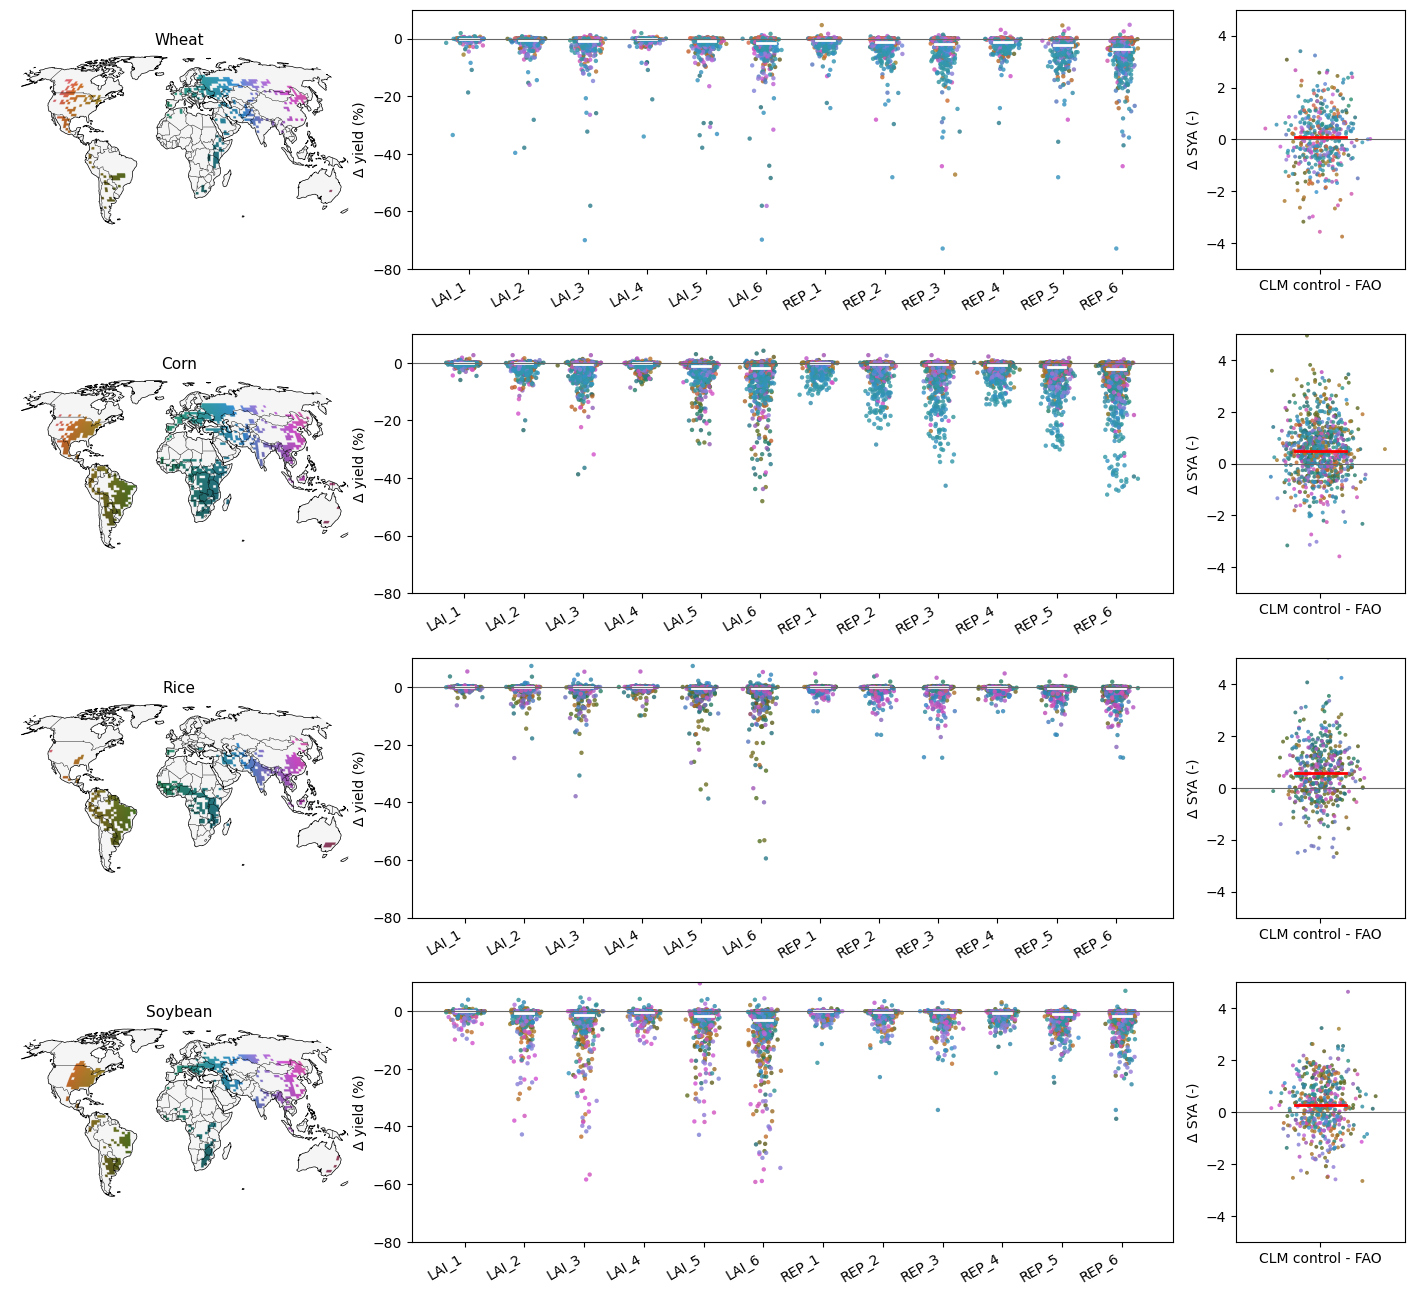

In [16]:
crops      = ['wheat', 'corn', 'rice', 'soybean']


fig = plt.figure(figsize=(18, 16))

outer = fig.add_gridspec(
    len(crops), 1,
    hspace=0.25
)

extent = [-180, 155, -58, 65]


experiments = [exp for exp in ds_detrends_dict.keys()
               if exp != 'ds_nostress']

for cropi, cropn in enumerate(crops):
    # --- data ---
    clm_SYA_all     = ds_detrends_dict['ds_nostress']['clm_yield_SYA'][:,cropi,:,:]
    fao_SYA_all     = ds_detrends_dict['ds_nostress']['fao_yield_SYA'][:,cropi,:,:]
    clm_abs_all     = ds_detrends_dict['ds_nostress']['clm_yield_abs'][:,cropi,:,:]

    # mask on temperature anomalies and negative yield anomalies
    timmask = txmask['Tanom_phase3'][cropi,:,:,:] >=  HW_ndays
    fao_SYA = fao_SYA_all.where(timmask)
    fao_SYA = fao_SYA.where(fao_SYA < diff_SYA)

    #totmask
    totmask = fao_SYA.max(dim='time').notnull()


    #for metrics
    # ensure alignment mask (same valid pixels)
    mask = fao_SYA.notnull().any(dim='time')
    
    clm_vals = clm_abs_all.where(mask)
    fao_vals = fao_SYA_all.where(mask)


    #filter other data on the same mask
    clm_SYA  = clm_SYA_all.where(fao_SYA.notnull())
    clm_abs  = clm_abs_all.where(fao_SYA.notnull())
    SYA_diff = clm_SYA - fao_SYA



    # -------------------------
    # position of crop panel
    # -------------------------

    row = cropi 

    inner = outer[row].subgridspec(
        1, 3,
        width_ratios=[1.2, 2.7, 0.6],
        wspace=0.15
    )
    ax_map  = fig.add_subplot(
        inner[0],
        projection=ccrs.Robinson()
    )
    
    ax_dist = fig.add_subplot(inner[1])
    
    ax_ref  = fig.add_subplot(inner[2])
    
    # crop-specific limits
    global_min = np.inf
    global_max = -np.inf

    # -----------------------------------------------------
    # masks
    # -----------------------------------------------------

    timmask = txmask['Tanom_phase3'][cropi,:,:,:] >= HW_ndays

    # aremask = (
    #     croparea[cropn] /
    #     croparea[cropn].max()
    # ) >= 0.05


    # -----------------------------------------------------
    # coordinates
    # -----------------------------------------------------

    lats = croparea[cropn]['lat'].values
    lons = croparea[cropn]['lon'].values

    lon2d, lat2d = np.meshgrid(lons, lats)

    # -----------------------------------------------------
    # color encoding
    # -----------------------------------------------------

    # same limits as the map
    lon_min, lon_max = -125, 155
    lat_min, lat_max = -50, 90
    
    # normalize coordinates within visible extent
    lon_norm = (lon2d - lon_min) / (lon_max - lon_min)
    lat_norm = (lat2d - lat_min) / (lat_max - lat_min)
    
    lon_norm = np.clip(lon_norm, 0, 1)
    lat_norm = np.clip(lat_norm, 0, 1)

    hue = lon_norm
    sat = 0.3 + 0.7 * lat_norm
    val = 0.7 + 0.3 * (1 - lat_norm)

    # cyclic longitude colours
    #rgb = plt.cm.CMRmap(lon_norm)[..., :3]
    cmap = ListedColormap(
        sns.color_palette("husl", 256)
    )
    
    rgb = cmap(lon_norm)[..., :3]
    
    # latitude controls brightness
    brightness = 0.5 + 0.5 * lat_norm
    
    rgb *= brightness[..., None]
    rgb = np.clip(rgb, 0, 1)
    
    # apply transparency mask
    rgba_mask = np.zeros((*totmask.shape, 4))
    rgba_mask[..., :3] = rgb
    rgba_mask[..., 3] = totmask.values.astype(float)

    # =====================================================
    # MAP
    # =====================================================

    # ax_map = fig.add_subplot(
    #     inner[0],
    #     projection=ccrs.Robinson()
    # )

    ax_map.add_feature(
        cfeature.LAND,
        facecolor='0.96'
    )

    ax_map.imshow(
        rgba_mask,
        extent=[lons.min(), lons.max(),
                lats.min(), lats.max()],
        transform=ccrs.PlateCarree(),
        origin='lower'
    )

    ax_map.coastlines(linewidth=0.5)
    ax_map.add_feature(
        cfeature.BORDERS,
        linewidth=0.3
    )

    ax_map.set_extent([-125, 155, -50, 90])

    ax_map.set_title(
        cropn.capitalize(),
        fontsize=11
    )

    # remove map frame
    ax_map.spines['geo'].set_visible(False)

    # =====================================================
    # DOTPLOT
    # =====================================================



    x = fao_SYA
    
    y_control = clm_SYA #clm_detrend

    for iexp, exp in enumerate(experiments):

        exp_SYA = (
            ds_detrends_dict[exp]
            ['clm_yield_SYA']
            [:, cropi, :, :]
        )
        exp_SYA = exp_SYA.where(fao_SYA.notnull())
        
        exp_abs = (
            ds_detrends_dict[exp]
            ['clm_yield_abs']
            [:, cropi, :, :]
        )
        exp_abs = exp_abs.where(fao_SYA.notnull()) 

        y = exp_abs
        #--------------------------- mean over location:
        ydiff = (((exp_abs - clm_abs)/clm_abs)*100).mean('time') # convert to percentage

        valid = np.isfinite(ydiff.values)
        
        vals = ydiff.values[valid]
        colors = rgb[valid]
        
        global_min = min(
            global_min,
            np.nanmin(vals)
        )

        global_max = max(
            global_max,
            np.nanmax(vals)
        )

        xpos = np.random.normal(
            iexp,
            0.10,
            len(vals)
        )

        ax_dist.scatter(
            xpos,
            vals,
            c=colors,
            s=10,
            alpha=0.8,
            linewidths=0,
            rasterized=True
        )

        median = np.nanmedian(vals)

        ax_dist.plot(
            [iexp-0.15, iexp+0.15],
            [median, median],
            color='w',
            lw=2
        )

    # --------------- reference dotplot (CLM - FAO)
    #dotplot:
    
    diff_mean = SYA_diff.mean(dim='time')
    
    valid_diff = np.isfinite(diff_mean.values)
    
    vals_diff = diff_mean.values[valid_diff]
    colors_diff = rgb[valid_diff]
    
    xpos = np.random.normal(
        0,
        0.10,
        len(vals_diff)
    )
    
    ax_ref.scatter(
        xpos,
        vals_diff,
        c=colors_diff,
        s=8,
        alpha=0.8,
        linewidths=0,
        rasterized=True
    )
    
    median = np.nanmedian(vals_diff)
    
    ax_ref.plot(
        [-0.15, 0.15],
        [median, median],
        color='r',
        lw=2
    )
    
    ax_ref.axhline(
        0,
        color='0.4',
        lw=0.8
    )
    
    ax_ref.set_xlim(-0.5, 0.5)
    ax_ref.set_ylim(-5, 5)
    ax_ref.set_xticks([0])
    ax_ref.set_xticklabels(['CLM control - FAO'])
    
    ax_ref.set_ylabel('Δ SYA (-)')

    
    # --------------- end add reference data FAO and CLM control
    
    ax_dist.set_ylim(-80, 10)
    ax_dist.set_yticks([-80, -60, -40, -20, 0])

    ax_dist.axhline(
        0,
        color='0.4',
        lw=0.8
    )

    ax_dist.set_xticks(
        np.arange(len(experiments))
    )

    labels = [exp.split('_', 2)[2] for exp in experiments]
    labels = ['REP_3' if label == 'REP_allvars_3' else label for label in labels]
    ax_dist.set_xticklabels(
        labels,
        rotation=30,
        ha='right'
    )

    ax_dist.set_ylabel('Δ yield (%)')

    if cropi >= 2:
        ax_dist.set_xlabel('')

#plt.savefig(f'{root}/paper1/figs/yield_dotplots_Tanomdiff.jpeg',dpi=400)

plt.show()

#### c. --------------- yield metrics

#### plot maps experiment 6

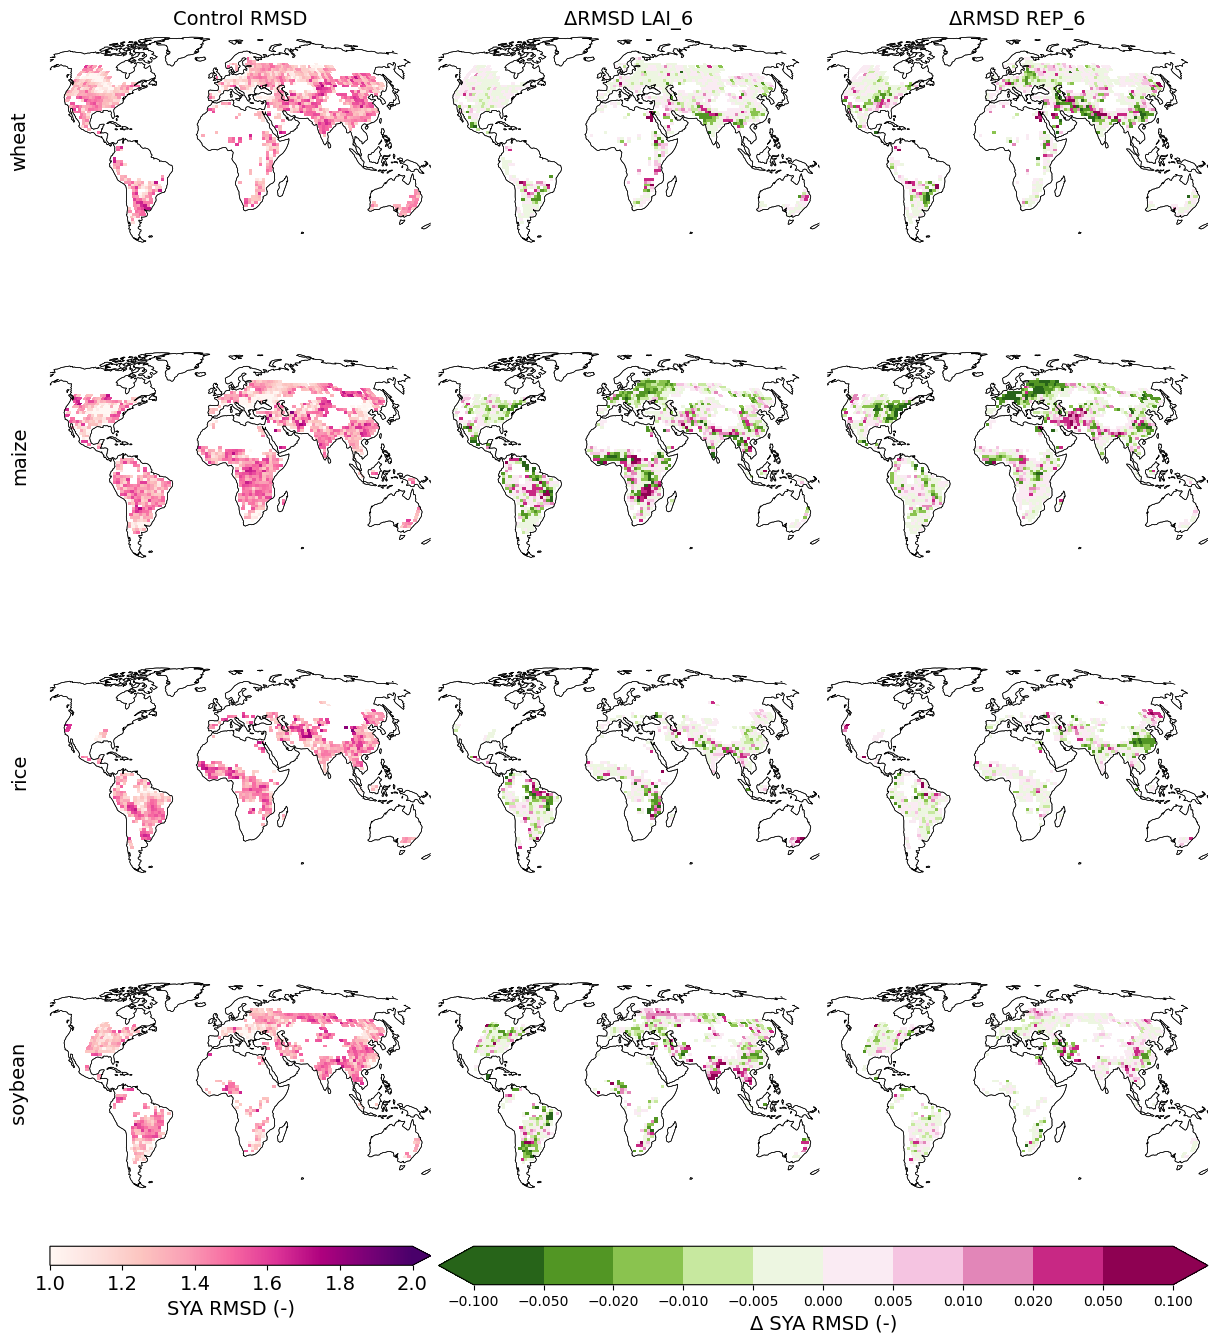

In [37]:
exprep = 'ds_TVpeak_REP_6'
explai = 'ds_TVpeak_LAI_6'
metric = 'RMSE'
exp0   ='ds_nostress'

# Figure

if metric == 'R':
    cmap = plt.cm.RdBu

    norm_control = mcolors.TwoSlopeNorm(
        vmin=-1,
        vcenter=0,
        vmax=1
    )
    
    bounds = [-0.2,-0.15,-0.1,-0.05,-0.02,-0.01,0,0.01,0.02,0.05,0.1,0.15, 0.2]
    norm_delta = mcolors.BoundaryNorm(
        boundaries=bounds,
        ncolors=cmap.N,
        clip=False
    )
    label = 'SYA correlation (R; -)'
    delta_label = 'Δ SYA R (-)'


elif metric == 'RMSE':
    cmap = plt.cm.PiYG_r
    cmapm = plt.cm.RdPu
    
    norm_control = mcolors.Normalize(
        vmin=1,
        vmax=2
    )
    
    bounds = [-0.1, -0.05,-0.02,-0.01,-0.005, 0, 0.005, 0.01, 0.02,0.05, 0.1]
    norm_delta = mcolors.BoundaryNorm(
        boundaries=bounds,
        ncolors=cmap.N,
        clip=True
    )
    label = 'SYA RMSD (-)'
    delta_label = 'Δ SYA RMSD (-)'




fig, axes = plt.subplots(
    4,
    3,
    figsize=(12,14),
    subplot_kw=dict(projection=ccrs.Robinson()),
    constrained_layout=True
)
fig.set_constrained_layout_pads(
    hspace=0.005,  # default ~0.02
    wspace=0.02,
    h_pad=0.01,
    w_pad=0.01
)

crop_names = ['wheat', 'maize', 'rice', ' soybean']


for cropi in range(4):
    # --- CLM data ---
    ds_SYA = ds_detrends_dict[exp0]['clm_yield_SYA'][:,cropi,:,:]
    ds_abs = ds_detrends_dict[exp0]['clm_yield_abs'][:,cropi,:,:]
    ds_exprep_SYA = ds_detrends_dict[exprep]['clm_yield_SYA'][:,cropi,:,:]
    ds_exprep_abs = ds_detrends_dict[exprep]['clm_yield_abs'][:,cropi,:,:]
    ds_explai_SYA = ds_detrends_dict[explai]['clm_yield_SYA'][:,cropi,:,:]
    ds_explai_abs = ds_detrends_dict[explai]['clm_yield_abs'][:,cropi,:,:]
    
    #FAO reference data
    fao_SYA = ds_detrends_dict[exp0]['fao_yield_SYA'][:,cropi,:,:]
    fao_abs = ds_detrends_dict[exp0]['fao_yield_abs'][:,cropi,:,:]
    
    # calc metrics:
    # -- control 
    r_control      = xr.corr(ds_SYA, fao_SYA, dim='time')
    rmse_control   = calc_rmse(ds_SYA, fao_SYA)
    
    # -- rep
    delta_r_rep    = xr.corr(ds_exprep_SYA, fao_SYA, dim='time') - r_control
    delta_rmse_rep = calc_rmse(ds_exprep_SYA, fao_SYA) - rmse_control
    
    # -- lai
    delta_r_lai    = xr.corr(ds_explai_SYA, fao_SYA, dim='time') - r_control
    delta_rmse_lai = calc_rmse(ds_explai_SYA, fao_SYA) - rmse_control

    # plot maps
    if metric == 'R':
        maps = [r_control,  delta_r_lai, delta_r_rep]
    elif metric == 'RMSE':
        maps = [rmse_control,  delta_rmse_lai, delta_rmse_rep]
        
    for col, da in enumerate(maps):

        ax = axes[cropi, col]

        if col == 0:
            norm = norm_control
        else:
            norm = norm_delta

        pcm = ax.pcolormesh(
            da.lon,
            da.lat,
            da,
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            norm=norm,
            shading='auto'
        )

        ax.coastlines(linewidth=0.5)
        ax.set_global()

        if cropi == 0:
            if metric == 'R':
                titles = [
                    'Control R',
                    'ΔR LAI_6',
                    'ΔR REP_6'
                ]
            elif metric =='RMSE':
                titles = [
                    'Control RMSD',
                    'ΔRMSD LAI_6',
                    'ΔRMSD REP_6'
                ]
            ax.set_title(titles[col], fontsize=14)

        if col == 0:
            ax.text(
                -0.08,
                0.5,
                crop_names[cropi],
                rotation=90,
                va='center',
                ha='center',
                transform=ax.transAxes,
                fontsize=14
            )
        # Robinson zoom
        ax.set_extent(
            [-125,155,-60,90],
            crs=ccrs.PlateCarree()
        )
        ax.add_feature(
        cfeature.LAND,
        facecolor='1.0')

        ax.coastlines(
            linewidth=0.4,
            color='black'
        )

        # remove globe outline
        if hasattr(ax, "spines"):
            ax.spines["geo"].set_visible(False)
        if col == 0 and metric == 'RMSE':
            pcm_control = ax.pcolormesh(
                da.lon,
                da.lat,
                da,
                transform=ccrs.PlateCarree(),
                cmap=cmapm,
                norm=norm_control,
                shading='auto'
            )

# ---------- colorbars ----------

# control colorbar
if metric == 'R':  
    cbar1 = fig.colorbar(
        plt.cm.ScalarMappable(norm=norm_control, cmap=cmap),
        ax=axes[:, 0],
        orientation='horizontal',
        fraction=0.035,
        extend='both', 
        pad=0.04
    )
    cbar1.set_label(label,fontsize=14)
    cbar1.ax.tick_params(labelsize=14)
elif metric == 'RMSE':

    cbar1 = fig.colorbar(
        pcm_control,
        ax=axes[:, 0],
        orientation='horizontal',
        fraction=0.035,
        pad=0.04,
        extend='max'
    )
    
    cbar1.set_label(label, fontsize=14)
    cbar1.ax.tick_params(labelsize=14)

# delta colorbar
cbar2 = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm_delta, cmap=cmap),
    ax=axes[:, 1:],
    orientation='horizontal',
    fraction=0.035,
    extend='both', 
    pad=0.04,
    ticks=bounds
)
cbar2.set_label(delta_label, fontsize=14)
# cbar2.set_ticklabels(
#     [f"{b:.2f}" for b in bounds],
#     rotation=45,
#     ha='right'
# )


plt.savefig(f'{root}/paper1/figs/yieldSYA_{metric}_6.jpeg',dpi=400)
plt.show()



### d. ------- plot time series for yearly maps

Found 33 valid locations


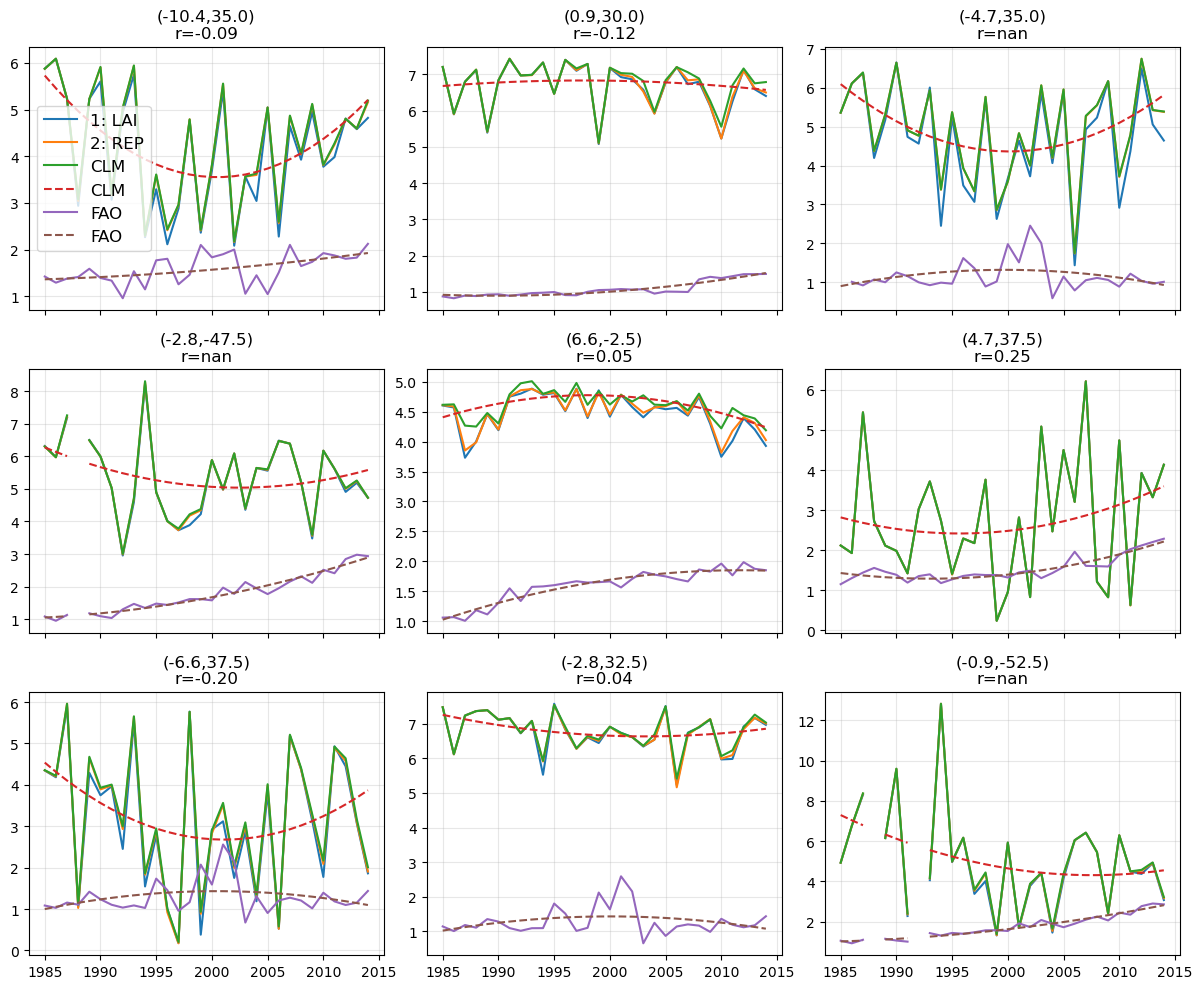

In [31]:
cropi = 1
# # domain
#lon_min, lon_max = 0, 20 #-120,-80 #AFR:-20,70  #{LA:(-90, -20),RU:20, 80 #EU:-15, 40 #US-120,#WS:-20,30 #
lat_min, lat_max = -14, 10 #48, 70  #0,50 #AFR:-50,35   #LA: -60, 10 #RU:40, 70 #EU:30, 70 #US0,50 #WS:0,20   #


Tanom_year = (
    txmask['Tanom_phase3']
    .sel(time=year)
    .isel(crop=cropi)
    > HW_ndays
)

# select spatial subset
mask_lat = (
    (ds_detrends_dict[exp0]['clm_yield_abs'].lat >= lat_min)
    & (ds_detrends_dict[exp0]['clm_yield_abs'].lat <= lat_max)
)

mask_lon = (
    (ds_detrends_dict[exp0]['clm_yield_abs'].lon >= lon_min)
    & (ds_detrends_dict[exp0]['clm_yield_abs'].lon <= lon_max)
)

# data for one crop
clm = ds_detrends_dict[exp0]['clm_yield_abs'][:, cropi, :, :]
clmtrend = ds_detrends_dict[exp0]['clm_yield_trend'][:, cropi, :, :]
lai = ds_detrends_dict[explai]['clm_yield_abs'][:, cropi, :, :]
laitrend = ds_detrends_dict[explai]['clm_yield_trend'][:, cropi, :, :]
rep = ds_detrends_dict[exprep]['clm_yield_abs'][:, cropi, :, :]
reptrend = ds_detrends_dict[exprep]['clm_yield_trend'][:, cropi, :, :]
fao = ds_detrends_dict[exp0]['fao_yield_abs'][:, cropi, :, :]
faotrend = ds_detrends_dict[exp0]['fao_yield_trend'][:, cropi, :, :]
#FAO reference data
fao_all = ds_detrends_dict[exp0]['fao_yield_SYA'][:, cropi, :, :]
clm_all = ds_detrends_dict[exp0]['clm_yield_SYA'][:, cropi, :, :]

# ------ include?? if CPHASE 2 or 3 is simulated end of year --> check for better fit with previous reference year
#minimum x years with a growing season overlapping the new calendar year
GS_risk = txmask['Tanom_transition'][cropi,:,:,:]
GS_risk_mask = GS_risk.notnull().sum(dim='time') >= 5

# Correlations used to diagnose timing mismatch
corr0 = xr.corr(fao_all,clm_all, dim='time')
corr1 = xr.corr(fao_all.shift(time=1), clm_all, dim='time')

# Shift only where improvement is meaningful
shift_mask = (
    GS_risk_mask &
    ((corr1 - corr0) > 0.3)
)

# Apply shift to SYA
shift_mask_3d = shift_mask.broadcast_like(fao_all)

fao = xr.where(
    shift_mask.broadcast_like(fao),
    fao.shift(time=1),
    fao
)
# -------------------------------

# valid pixels (at least 10 common years)
valid = (
    (clm.notnull().sum('time') >= 10)
    & (fao.notnull().sum('time') >= 10)
    & mask_lat
    & mask_lon
    & Tanom_year
)

# coordinates of valid pixels
lat_idx, lon_idx = np.where(valid.values)

print(f"Found {len(lat_idx)} valid locations")

nplots = 9

rng = np.random.default_rng()

choice = rng.choice(len(lat_idx), size=min(nplots, len(lat_idx)), replace=False)

fig, axes = plt.subplots(3, 3, figsize=(12, 10), sharex=True)

for ax, i in zip(axes.flat, choice):

    ilat = lat_idx[i]
    ilon = lon_idx[i]


    lai_ts = lai[:, ilat, ilon]
    rep_ts = rep[:, ilat, ilon]
    clm_ts = clm[:, ilat, ilon]
    clmtrend_ts = clmtrend[:, ilat, ilon]
    fao_ts = fao[:, ilat, ilon]
    faotrend_ts = faotrend[:, ilat, ilon]

    lat = float(clm.lat[ilat])
    lon = float(clm.lon[ilon])

    ax.plot(lai.time, lai_ts, label='1: LAI')
    ax.plot(rep.time, rep_ts, label='2: REP')
    ax.plot(clm.time, clm_ts, label='CLM')
    ax.plot(clmtrend.time, clmtrend_ts, label='CLM', linestyle ='--')
    ax.plot(fao.time, fao_ts, label='FAO')
    ax.plot(faotrend.time, faotrend_ts, label='FAO', linestyle ='--')

    ax.set_title(f"{lat:.2f}°N, {lon:.2f}°E")
    ax.grid(alpha=0.3)

    r = np.corrcoef(
        clm_ts.values,
        fao_ts.values
    )[0, 1]
    
    ax.set_title(
        f"({lat:.1f},{lon:.1f})\nr={r:.2f}"
    )

axes.flat[0].legend(fontsize=12)

plt.tight_layout()
plt.show()




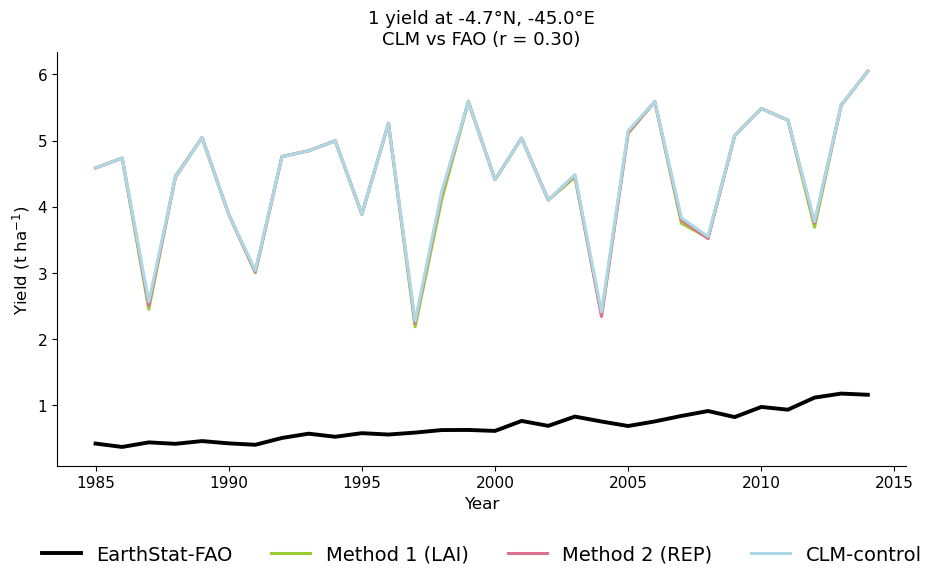

In [32]:
lat_sel =-4 #57.8 #-10.4#-10.4 #50.2 #-4.7#-2.8 
lon_sel = -45 #47.5 #-42.5 #-45 #10 #-47#-52.5


# nearest grid cell
ilat = np.abs(clm.lat - lat_sel).argmin().item()
ilon = np.abs(clm.lon - lon_sel).argmin().item()

lai_ts = lai[:, ilat, ilon]
rep_ts = rep[:, ilat, ilon]
clm_ts = clm[:, ilat, ilon]
fao_ts = fao[:, ilat, ilon]

# actual grid coordinates
lat = float(clm.lat[ilat])
lon = float(clm.lon[ilon])

# correlation
valid = np.isfinite(clm_ts) & np.isfinite(fao_ts)
r = np.corrcoef(
    clm_ts.where(valid, drop=True),
    fao_ts.where(valid, drop=True)
)[0, 1]

# Okabe-Ito palette
colors = {
    "fao": 'black',   
    "clm": 'lightblue',  
    "lai": 'yellowgreen',  
    "rep": 'palevioletred', 
}

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    fao.time,
    fao_ts,
    color=colors["fao"],
    lw=2.8,
    label="EarthStat-FAO"
)

ax.plot(
    lai.time,
    lai_ts,
    color=colors["lai"],
    lw=2.2,
    label="Method 1 (LAI)"
)

ax.plot(
    rep.time,
    rep_ts,
    color=colors["rep"],
    lw=2.2,
    label="Method 2 (REP)"
)

ax.plot(
    clm.time,
    clm_ts,
    color=colors["clm"],
    lw=2.2,
    label="CLM-control"
)

# remove grid
ax.grid(False)

# cleaner axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_ylabel("Yield (t ha$^{-1}$)", fontsize=12)
ax.set_xlabel("Year", fontsize=12)

ax.set_title(
    f"{cropi} yield at {lat:.1f}°N, {lon:.1f}°E\n"
    f"CLM vs FAO (r = {r:.2f})",
    fontsize=13
)

ax.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=4,
    fontsize=14
)

ax.tick_params(labelsize=11)

plt.tight_layout()
#plt.savefig(f'{root}/paper1/figs/yield_tsb_{cropi}_{region}_{exp}.jpeg',dpi=400)
plt.show()